# House price prediction with Groovy

Linear regression over the
[Kaggle house sale prices for King County](https://www.kaggle.com/harlfoxem/housesalesprediction/data)
dataset (~21.6k actual sales with per-house features), ported from the
BeakerX-era `HousePrices.ipynb` in
[groovy-data-science](https://github.com/paulk-asert/groovy-data-science).

The dataset ships alongside this notebook **gzipped** (`kc_house_data.csv.gz`,
0.7 MB instead of 2.5 MB — see `kc_house_data_source.txt` for provenance);
`CsvSlurper` reads it straight off a `GZIPInputStream`. Regression uses
ordinary least squares from Smile 1.5.3 (the last Apache-2.0-licensed
release). The story: single features are weak predictors of price, and we
climb from bedrooms to a multi-feature model.

In [1]:
@Grab('com.github.haifengl:smile-core:1.5.3')
import groovy.csv.CsvSlurper
import smile.regression.OLS
import java.util.zip.GZIPInputStream
'deps ready'

deps ready

In [2]:
rows = new CsvSlurper().parse(new GZIPInputStream(new FileInputStream('kc_house_data.csv.gz')))
"${rows.size()} rows X ${rows[0].size()} cols"

21613 rows X 21 cols

### Exploring the data

Any suspiciously large houses? One record claims 33 bedrooms — a well-known
data-entry error in this dataset:

In [3]:
rows.findAll { (it.bedrooms as int) > 10 }

id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
1773100755,20140821T000000,520000,11,3,3000,4960,2,0,0,3,7,2400,600,1918,1999,98106,47.556,-122.363,1420,4960
2402100895,20140625T000000,640000,33,1.75,1620,6000,1,0,0,5,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


In [4]:
houses = rows.findAll { (it.bedrooms as int) <= 30 }
"${houses.size()} rows after dropping the 33-bedroom outlier"

21612 rows after dropping the 33-bedroom outlier

Bathroom counts as a histogram (hand-rolled SVG bars — hover for counts):

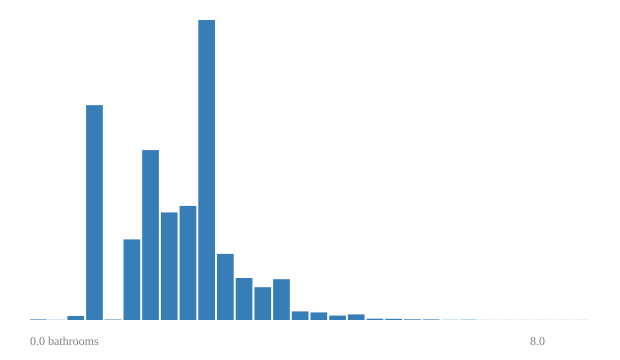

In [5]:
baths = houses.collect { it.bathrooms as double }
bins = baths.countBy { it }.sort { it.key }
maxCount = bins.values().max()
barW = (560 / bins.size()).round(1)
bars = bins.entrySet().withIndex().collect { entry, i ->
    def h = (300 * entry.value / maxCount).round(1)
    "<rect x='${(30 + i * barW).round(1)}' y='${(320 - h).round(1)}' width='${(barW - 2).round(1)}' height='$h' fill='#377eb8'><title>${entry.key} bathrooms: ${entry.value} houses</title></rect>"
}.join('\n')
displaySvg("<svg xmlns='http://www.w3.org/2000/svg' width='620' height='360'>\n$bars\n" +
    "<text x='30' y='345' font-size='12' fill='gray'>${bins.keySet().min()} bathrooms</text>\n" +
    "<text x='530' y='345' font-size='12' fill='gray'>${bins.keySet().max()}</text>\n</svg>")
null

### Linear regression

Do more bedrooms mean a higher price? Fit ordinary least squares per feature
and compare R² (closer to 1 = better fit):

In [6]:
target = houses.collect { it.price as double } as double[]
olsFor = { List<String> feats ->
    def xs = houses.collect { h -> feats.collect { h[it] as double } as double[] } as double[][]
    new OLS(xs, target)
}
['bedrooms', 'bathrooms', 'sqft_living'].collect { f ->
    [feature: f, rSquared: olsFor([f]).RSquared().round(3)]
}

feature,rSquared
bedrooms,0.1
bathrooms,0.276
sqft_living,0.493


Living area is the best single feature. Scatter it against price (a ~6% random
sample of the 21.6k points, to keep the SVG light) with the fitted line:

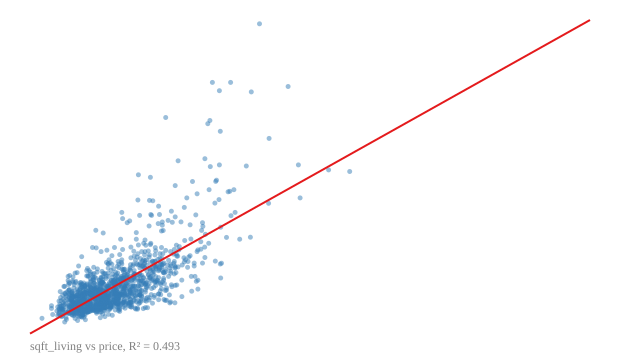

In [7]:
model = olsFor(['sqft_living'])
rnd = new Random(42)
sample = houses.findAll { rnd.nextDouble() < 0.06 }
xs = sample.collect { it.sqft_living as double }
ys = sample.collect { it.price as double }
maxX = houses.collect { it.sqft_living as double }.max()
pMax = model.predict([maxX] as double[])
p0 = model.predict([0d] as double[])
maxY = [ys.max(), pMax].max()
sx = { v -> (30 + 560 * v / maxX).round(1) }
sy = { v -> (330 - 310 * v / maxY).round(1) }
dots = (0..<xs.size()).collect {
    "<circle cx='${sx(xs[it])}' cy='${sy(ys[it])}' r='2.5' fill='#377eb8' fill-opacity='0.5'/>"
}.join('\n')
displaySvg("<svg xmlns='http://www.w3.org/2000/svg' width='620' height='360'>\n$dots\n" +
    "<line x1='${sx(0)}' y1='${sy(p0)}' x2='${sx(maxX)}' y2='${sy(pMax)}' stroke='#e41a1c' stroke-width='2'/>\n" +
    "<text x='30' y='350' font-size='12' fill='gray'>sqft_living vs price, R² = ${model.RSquared().round(3)}</text>\n</svg>")
null

Better, but a multi-feature model does better still:

In [8]:
feats = ['sqft_living', 'bathrooms', 'grade', 'view', 'bedrooms',
         'sqft_above', 'yr_renovated', 'waterfront']
multi = olsFor(feats)
"8-feature model: R² = ${multi.RSquared().round(3)} (adjusted ${multi.adjustedRSquared().round(3)})"

8-feature model: R² = 0.601 (adjusted 0.601)

With 8 features there's nothing left to plot directly — so plot **actual vs
predicted** price for the same sample; a perfect model would put every point
on the diagonal:

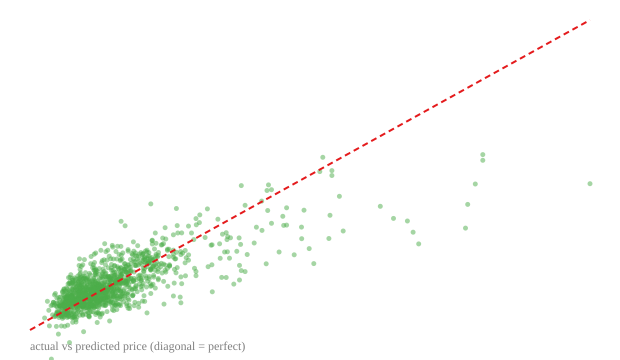

In [9]:
actuals = sample.collect { it.price as double }
predicted = sample.collect { h -> multi.predict(feats.collect { h[it] as double } as double[]) }
lim = [actuals.max(), predicted.max()].max()
s = { v -> (30 + 560 * v / lim).round(1) }
t = { v -> (330 - 310 * v / lim).round(1) }
pts = (0..<actuals.size()).collect {
    "<circle cx='${s(actuals[it])}' cy='${t(predicted[it])}' r='2.5' fill='#4daf4a' fill-opacity='0.5'/>"
}.join('\n')
displaySvg("<svg xmlns='http://www.w3.org/2000/svg' width='620' height='360'>\n$pts\n" +
    "<line x1='${s(0)}' y1='${t(0)}' x2='${s(lim)}' y2='${t(lim)}' stroke='#e41a1c' stroke-width='2' stroke-dasharray='6,4'/>\n" +
    "<text x='30' y='350' font-size='12' fill='gray'>actual vs predicted price (diagonal = perfect)</text>\n</svg>")
null